# Uniform-Cost Search and Dijkstra's Algorithm

A route with fewer edges is not necessarily cheaper. Uniform-cost search (UCS) expands the frontier entry with the lowest accumulated cost, rather than the smallest depth.

This notebook builds a weighted graph, traces a least-cost route, and then finds routes to every reachable node from the same source. Run the cells from top to bottom. The external packages are NetworkX, Matplotlib, and NumPy; the other imports belong to Python's standard library.


## Imports

NetworkX stores nodes, edges, and edge weights. Matplotlib draws the graph. Both random-number generators are seeded below so the graph and its initial layout can be reproduced.


In [ ]:
# generate random weighted graphs and show it
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np



## Generate a Weighted Graph

<code>generate_random_graph(n, m, seed)</code> creates an undirected graph with integer node labels. It rejects self-loops and duplicate edges, then assigns each accepted edge a cost from 1 through 10.

Choose at most <code>n * (n - 1) // 2</code> edges: a larger request would leave the sampling loop unable to finish. Random generation does not guarantee connectivity, so some targets may be unreachable.


In [ ]:
def generate_random_graph(n, m, seed):
    # n: number of nodes
    # m: number of edges
    # seed: random seed
    random.seed(seed)
    np.random.seed(seed)
    G = nx.Graph()
    for i in range(n):
        G.add_node(i)
    for i in range(m):
        # get an edge that is not in the graph
        while True:
            u = random.randint(0, n-1)
            v = random.randint(0, n-1)
            if u == v:
                continue # no self loop
            if not G.has_edge(u, v):
                break
        w = random.randint(1, 10)
        G.add_edge(u, v, weight=w)
    return G



## Draw Nodes and Edge Costs

<code>show_graph(G)</code> returns the positions used by the drawing. Later search frames reuse these positions, so nodes do not move as the frontier changes. The numbers on edges are travel costs; geometric distances on the screen are not costs.


In [ ]:
def show_graph(G):
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()
    return pos




## Example Graph

The example has eight nodes and twelve edges. Before searching from node 0 to node 3, compare a route with few edges against a route whose edge weights have a small sum.


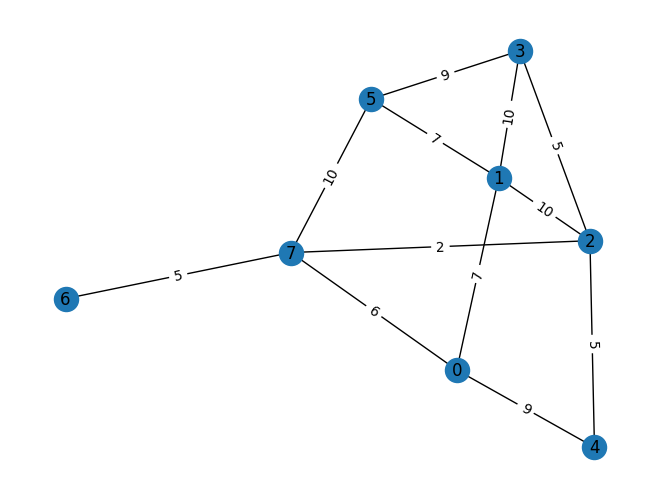

In [ ]:
G = generate_random_graph(8, 12, 0)
pos = show_graph(G)

## Priority Queue and Query

Python's <code>heapq</code> maintains a min-heap. Each search entry is <code>(cost, node, parent)</code>, so the lowest total cost is removed first. Equal-cost entries are ordered by node label in this example.


In [ ]:
import heapq

source = 0
target = 3
# find the shortest path from source to target, using uniform cost search


## Uniform-Cost Search

The loop removes a cheapest entry, skips an already finalized node, and records its parent. A node becomes <code>visited</code> when it is removed, not when first discovered: a cheaper route may be found while it is still in the frontier.

With nonnegative weights, the first removal of a node finalizes its shortest-path cost. The goal test therefore belongs after removal. On reaching the target, parent links are followed backward and the list is reversed into source-to-target order.

Neighbor entries may duplicate a node already in the heap. The <code>visited</code> check discards those stale alternatives. If the heap empties first, the function returns <code>None</code>.


In [ ]:
def uniform_cost_search(G, source, target):
    visited = set()
    queue = [(0, source, [])]
    all_parents = {}
    heapq.heapify(queue)
    while len(queue) > 0:
        print(queue)
        cost, node, parent = heapq.heappop(queue)
        # draw a picture of the search process
        nx.draw(G, pos, with_labels=True)
        labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        nx.draw_networkx_nodes(G, pos, nodelist=visited, node_color='r') # visited nodes
        nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color='g') # current node
        plt.show()
        
        if node in visited:
            continue
        visited.add(node)
        all_parents[node] = parent
        if node == target:
            path = [node]
            while node != source:
                node = all_parents[node]
                path.append(node)
            path.reverse()
            return path
        for neighbor in G.neighbors(node):
            if neighbor in visited:
                continue
            weight = G[node][neighbor]['weight']
            heapq.heappush(queue, (cost + weight, neighbor, node))
    return None



## Trace the Search

Green marks the current popped node; red marks previously finalized nodes. Drawing occurs before the duplicate check, so a stale entry can also produce a frame.

The printed list is the heap's internal storage, not a fully sorted list. Only its first entry is guaranteed to have minimum priority. The final printed list is the route; add the weights along its edges to obtain its cost.


[(0, 0, [])]


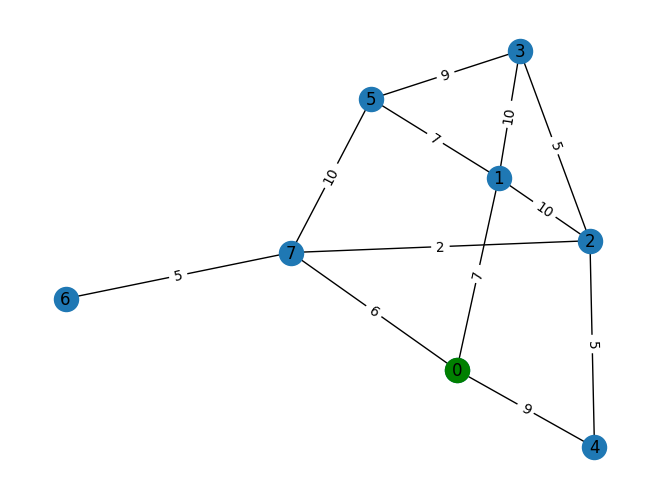

[(6, 7, 0), (9, 4, 0), (7, 1, 0)]


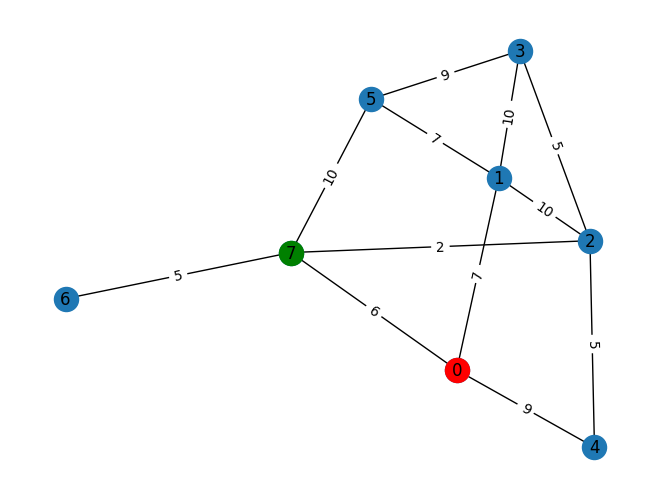

[(7, 1, 0), (8, 2, 7), (11, 6, 7), (16, 5, 7), (9, 4, 0)]


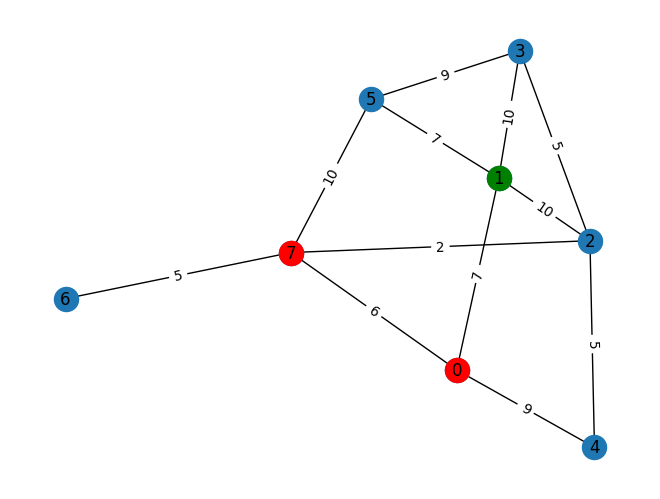

[(8, 2, 7), (9, 4, 0), (11, 6, 7), (16, 5, 7), (17, 2, 1), (14, 5, 1), (17, 3, 1)]


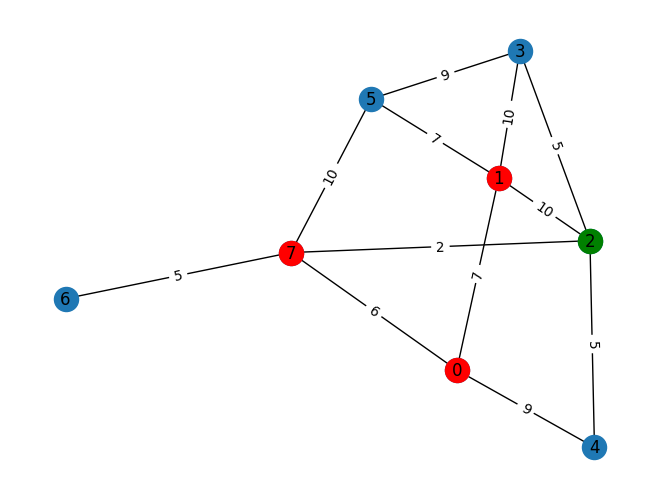

[(9, 4, 0), (13, 4, 2), (11, 6, 7), (16, 5, 7), (17, 2, 1), (14, 5, 1), (13, 3, 2), (17, 3, 1)]


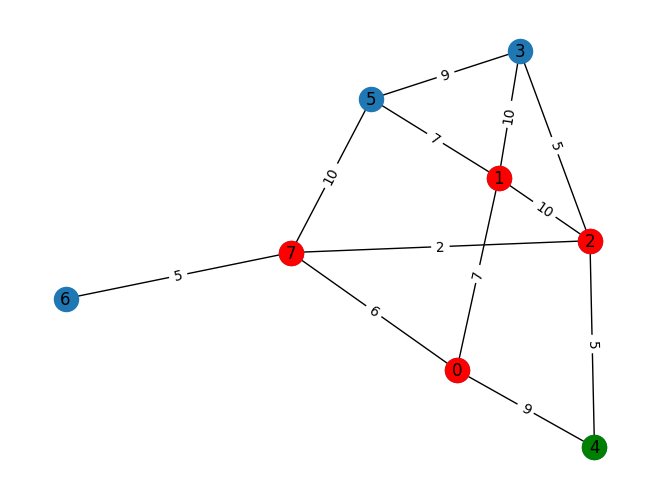

[(11, 6, 7), (13, 4, 2), (13, 3, 2), (16, 5, 7), (17, 2, 1), (14, 5, 1), (17, 3, 1)]


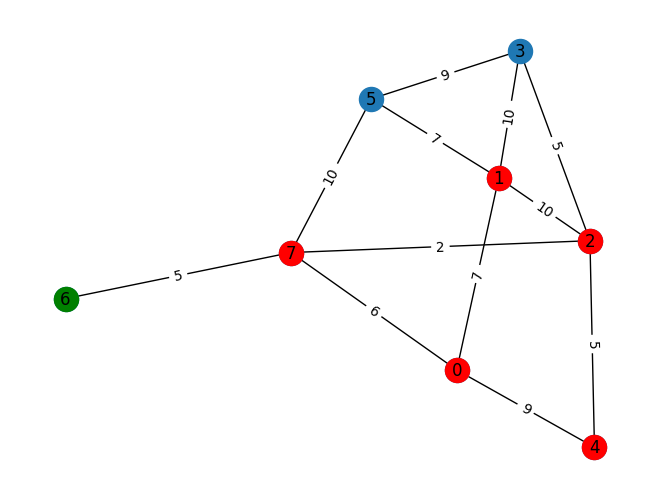

[(13, 3, 2), (13, 4, 2), (14, 5, 1), (16, 5, 7), (17, 2, 1), (17, 3, 1)]


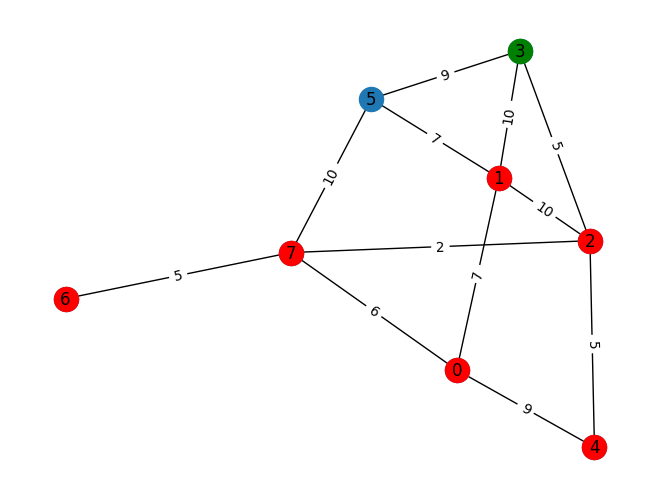

[0, 7, 2, 3]


In [ ]:
path = uniform_cost_search(G, source, target)
print(path)

## Dijkstra: One Source, Every Reachable Target

This version continues until the frontier is empty. It returns a dictionary mapping each reachable node to <code>(cost, path)</code>. Despite the original code comment, this is **single-source**, not all-pairs, shortest paths.

Here each heap entry carries an entire path instead of one parent. Copying paths makes the example easy to inspect but uses extra memory. A larger implementation would usually track best distances and parent pointers separately.


In [ ]:
# dijkstra's algorithm for every pair shortest path
def dijkstra(G, source):
    visited = set()
    queue = [(0, source, [])]
    shortest_paths = {}
    heapq.heapify(queue)
    while len(queue) > 0:
        cost, node, path = heapq.heappop(queue)
        if node in visited:
            continue
        visited.add(node)
        path = path + [node]
        shortest_paths[node] = (cost, path)
        for neighbor in G.neighbors(node):
            if neighbor in visited:
                continue
            weight = G[node][neighbor]['weight']
            heapq.heappush(queue, (cost + weight, neighbor, path))
    return shortest_paths



## Read the Results

Each line shows a destination and its route from node 0. The dictionary also stores the total cost, although the loop below prints only the path. Unreachable nodes are absent.

The route to node 3 should agree in cost with UCS. Equal-cost alternatives need not use exactly the same route.


In [ ]:
shortest_paths = dijkstra(G, source)
for node, (cost, path) in shortest_paths.items():
    print(f'{node}: {path}')




0: [0]
7: [0, 7]
1: [0, 1]
2: [0, 7, 2]
4: [0, 4]
6: [0, 7, 6]
3: [0, 7, 2, 3]
5: [0, 1, 5]


## Compare and Explore

- Give every edge weight 1. How does the optimal cost relate to the number of edges found by BFS?
- Change the target. Which UCS frames disappear because search stops earlier?
- Inspect <code>shortest_paths[target][0]</code> and sum the weights on the returned route.
- Why would a negative edge invalidate the claim that the first removal finalizes a node?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Unit weights recover minimum depth.** A route's cost equals its number of edges, so UCS and BFS find the same optimal path length. Tie-breaking can still produce different routes of that length.
2. **Stop at the new goal's removal.** With node 2 as the target, the saved expansion order ends after 0, 7, 1, 2. The later frames for nodes 4, 6, and 3 disappear. A different target is not necessarily reached earlier; the result depends on its least-cost distance and tie-breaking.
3. **The saved route costs 13.** For target 3, the route is `0 -> 7 -> 2 -> 3`, with edge costs `6 + 2 + 5 = 13`. This agrees with `shortest_paths[3][0]`. Three edges do not mean a cost of three unless every weight is one.
4. **A later route could become cheaper.** In a directed example with edges `S -> A: 1`, `S -> B: 2`, and `B -> A: -3`, A would be finalized at cost 1 before the route through B reveals cost -1. Nonnegative weights prevent that decrease. In this notebook's undirected graph, a negative edge additionally creates a negative-cost back-and-forth walk, so a finite shortest-walk cost may not exist.

</details>

**Takeaway:** UCS and Dijkstra use the same cheapest-first principle. Their stopping conditions differ: one target versus every reachable target.
